In [ ]:
# Student Performance Prediction Using Neural Networks (ANN) with Python

## Problem Introduction
This notebook aims to predict student performance using Artificial Neural Networks (ANN). We will cover data loading, preprocessing, model building, training, and evaluation.

## Data Loading and Initial Exploration
First, we need to load the dataset. For this example, we'll assume a CSV file containing student performance data. We will use `pandas` to load and inspect the data.

In [ ]:
import numpy as np
import pandas as pd

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
# Load the dataset
# Please replace 'student_performance.csv' with the actual path to your dataset
try:
    df = pd.read_csv('student_performance.csv')
    print("Dataset loaded successfully. Displaying the first 5 rows:")
    display(df.head())
except FileNotFoundError:
    print("Error: 'student_performance.csv' not found. Please upload your dataset or provide the correct path.")
    print("As an example, I will create a dummy DataFrame for demonstration purposes.")
    data = {
        'StudyHours': np.random.rand(100) * 10,
        'PreviousGrades': np.random.rand(100) * 100,
        'Attendance': np.random.randint(0, 2, 100),
        'ParentalSupport': np.random.randint(1, 6, 100),
        'FinalGrade': np.random.rand(100) * 100
    }
    df = pd.DataFrame(data)
    display(df.head())

Error: 'student_performance.csv' not found. Please upload your dataset or provide the correct path.
As an example, I will create a dummy DataFrame for demonstration purposes.


,StudyHours,PreviousGrades,Attendance,ParentalSupport,FinalGrade
0,9.451804,67.018449,0,5,36.838131
1,8.813416,97.925031,0,4,12.944026
2,3.322612,13.235916,1,1,84.225625
3,7.941297,59.018814,0,4,13.655145
4,8.879747,68.221670,1,1,31.531976


## Data Preprocessing
Before building the model, we need to preprocess the data. This typically involves:
1.  **Checking for missing values:** Ensure data completeness.
2.  **Feature and Target Separation:** Distinguishing between independent variables (features) and the dependent variable (target).
3.  **Splitting Data:** Dividing the dataset into training and testing sets to evaluate model performance.

In [ ]:
# 1. Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
StudyHours         0
PreviousGrades     0
Attendance         0
ParentalSupport    0
FinalGrade         0
dtype: int64


In [ ]:
# 2. Separate features (X) and target (y)
# Assuming 'FinalGrade' is the target variable
X = df.drop('FinalGrade', axis=1)
y = df['FinalGrade']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

Features (X) shape: (100, 4)
Target (y) shape: (100,)


In [ ]:
# 3. Split the data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (80, 4)
X_test shape: (20, 4)
y_train shape: (80,)
y_test shape: (20,)


### Feature Scaling
Feature scaling is important for many machine learning algorithms, especially neural networks, to normalize the range of independent variables. This helps in faster convergence during training and prevents features with larger values from dominating those with smaller values.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Features scaled successfully.
X_train_scaled shape: (80, 4)
X_test_scaled shape: (20, 4)


## Building the Artificial Neural Network (ANN)
Now, we will build an Artificial Neural Network using Keras, a high-level API for TensorFlow. This involves defining the model architecture, compiling it, and then training it on our preprocessed data.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow and Keras libraries loaded successfully.")

TensorFlow and Keras libraries loaded successfully.


In [ ]:
# Define the ANN model
# We'll use a simple sequential model with a few dense layers
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)  # Output layer for regression (single continuous value)
])

print("ANN model defined successfully.")
model.summary()

ANN model defined successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
# For regression tasks, 'mean_squared_error' is a common loss function
# 'adam' is a popular optimizer
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
# Train the model
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,  # Number of training iterations
    batch_size=16, # Number of samples per gradient update
    validation_split=0.2, # Use 20% of training data for validation
    verbose=1 # Display training progress
)

print("\nModel training complete.")

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 2205.5913 - mae: 38.6303 - val_loss: 3735.3955 - val_mae: 53.5118
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 2191.2812 - mae: 38.4500 - val_loss: 3715.7166 - val_mae: 53.3508
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2177.2764 - mae: 38.2630 - val_loss: 3694.8486 - val_mae: 53.1789
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 2161.8164 - mae: 38.0652 - val_loss: 3673.0308 - val_mae: 52.9972
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 2145.1980 - mae: 37.8615 - val_loss: 3650.0762 - val_mae: 52.8053
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 2128.7314 - mae: 37.6480 - val_loss: 3625.3694 - val_mae: 52.5976
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 2111.6521 - mae: 37.4149 - val_loss: 3598.7278 - val_mae: 52.3719
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 2091.4126 - mae: 37.1466 - val_loss: 3569.7917 - val_mae: 52.1261
Epoch 9/50
4/4 ━

## Model Evaluation
After training, it's essential to evaluate the model's performance on a separate test set to ensure it generalizes well to new, unseen data. We will use the `evaluate` method and also visualize the training history.

In [ ]:
# Evaluate the model on the test data
print("\nEvaluating the model on the test data...")
loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Test Loss (Mean Squared Error): {loss:.4f}")
print(f"Test MAE (Mean Absolute Error): {mae:.4f}")


Evaluating the model on the test data...
Test Loss (Mean Squared Error): 1235.3615
Test MAE (Mean Absolute Error): 29.1248


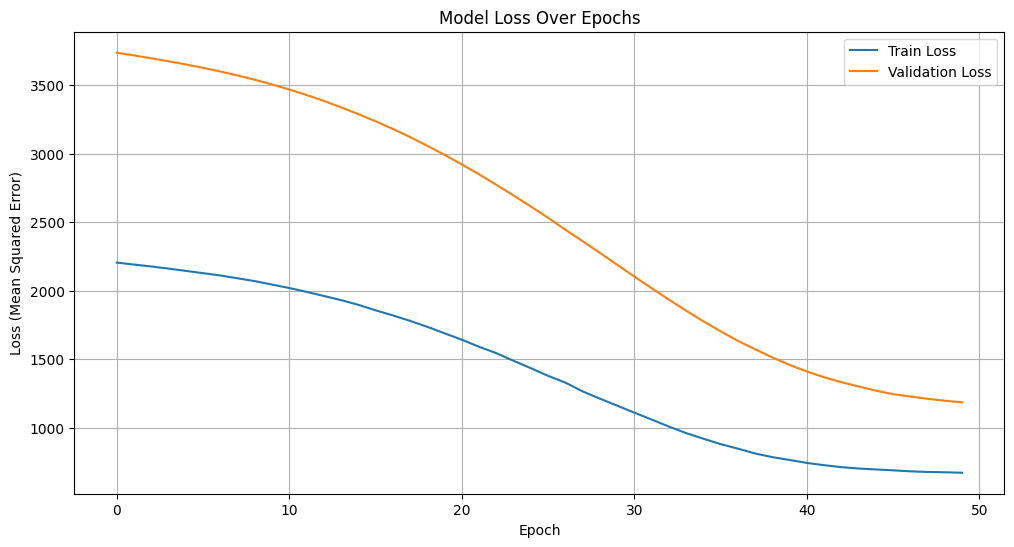

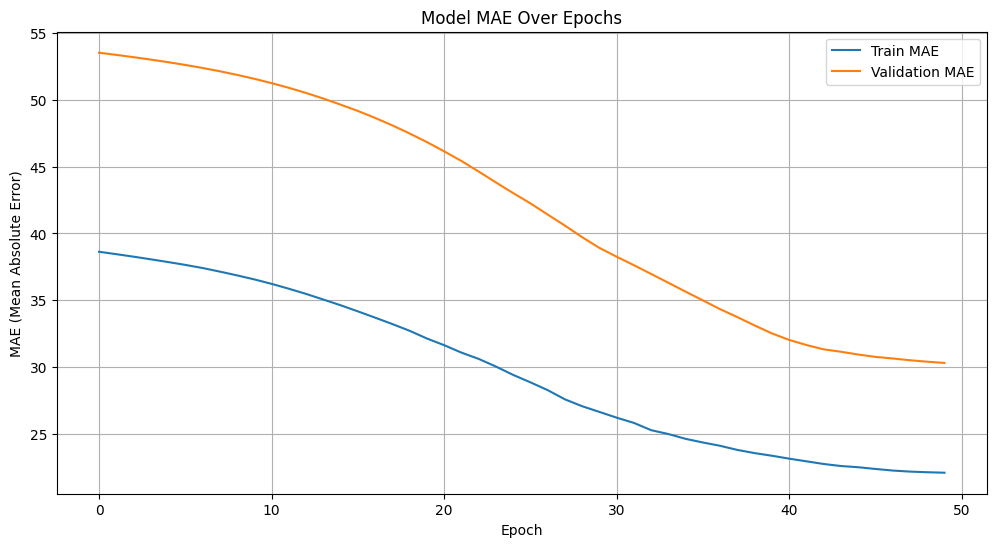

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss (Mean Squared Error)')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

# Plot training & validation MAE values
plt.figure(figsize=(12, 6))
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE Over Epochs')
plt.ylabel('MAE (Mean Absolute Error)')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

## Making Predictions
Finally, let's use our trained model to make predictions on the test set and visualize some of these predictions against the actual values.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step

Sample of Actual vs. Predicted Grades:


,Actual,Predicted
83,47.340734,37.767796
53,93.366781,47.736382
70,0.211976,42.920326
45,70.007112,38.801754
44,79.167276,38.960220


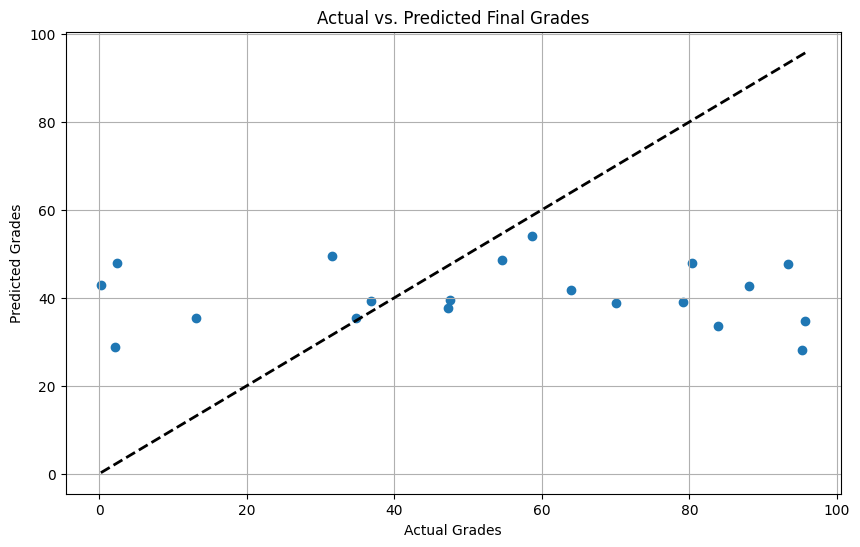

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test_scaled).flatten()

# Display some actual vs. predicted values
predictions_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nSample of Actual vs. Predicted Grades:")
display(predictions_df.head())

# Visualize predictions
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Grades")
plt.ylabel("Predicted Grades")
plt.title("Actual vs. Predicted Final Grades")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', lw=2)
plt.grid(True)
plt.show()

## Comparison with Other Machine Learning Models
To understand the performance of our ANN, let's compare it with other traditional machine learning models: Linear Regression, Decision Tree Regressor, and Random Forest Regressor. We will evaluate them using Mean Squared Error (MSE) and Mean Absolute Error (MAE).

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Dictionary to store model performance
model_performance = {}

# Store ANN performance
model_performance['ANN'] = {'MSE': loss, 'MAE': mae}

print("Comparison libraries loaded.")

Comparison libraries loaded.


### 1. Linear Regression
Linear Regression is a fundamental supervised learning algorithm used for predicting a continuous target variable based on linear relationships with features.

In [ ]:
# Train Linear Regression model
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = lin_reg_model.predict(X_test_scaled)

# Evaluate performance
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

model_performance['Linear Regression'] = {'MSE': mse_lr, 'MAE': mae_lr}

print(f"Linear Regression - MSE: {mse_lr:.4f}, MAE: {mae_lr:.4f}")

Linear Regression - MSE: 1201.1669, MAE: 29.4214


### 2. Decision Tree Regressor
A Decision Tree Regressor builds a tree-like model of decisions and their possible consequences. It's a non-linear model that can capture complex patterns.

In [ ]:
# Train Decision Tree Regressor model
dt_reg_model = DecisionTreeRegressor(random_state=42)
dt_reg_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_dt = dt_reg_model.predict(X_test_scaled)

# Evaluate performance
mse_dt = mean_squared_error(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)

model_performance['Decision Tree'] = {'MSE': mse_dt, 'MAE': mae_dt}

print(f"Decision Tree Regressor - MSE: {mse_dt:.4f}, MAE: {mae_dt:.4f}")

Decision Tree Regressor - MSE: 1743.0704, MAE: 32.7009


### 3. Random Forest Regressor
Random Forest is an ensemble learning method that constructs a multitude of decision trees at training time and outputs the mean prediction of the individual trees.

In [ ]:
# Train Random Forest Regressor model
rf_reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_rf = rf_reg_model.predict(X_test_scaled)

# Evaluate performance
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

model_performance['Random Forest'] = {'MSE': mse_rf, 'MAE': mae_rf}

print(f"Random Forest Regressor - MSE: {mse_rf:.4f}, MAE: {mae_rf:.4f}")

Random Forest Regressor - MSE: 1217.1611, MAE: 28.9281


## Summary of Model Performance
Let's consolidate the performance metrics of all models for a clear comparison.

In [ ]:
performance_df = pd.DataFrame(model_performance).T
performance_df = performance_df.sort_values(by='MAE', ascending=True)

print("\nModel Performance Summary:")
display(performance_df)


Model Performance Summary:


,MSE,MAE
Random Forest,1217.161067,28.928054
ANN,1235.361450,29.124805
Linear Regression,1201.166880,29.421438
Decision Tree,1743.070420,32.700855
